In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
# Open connection to SQLite database
conn = sqlite3.connect('../data/streaming_warehouse.db')

In [3]:
# Check top 10 rows of stg_streaming_activity
top_users_query = """
SELECT *
FROM stg_streaming_activity
LIMIT 10
"""

df_top_users = pd.read_sql_query(top_users_query, conn)
display(df_top_users)

,log_id,user_id,activity_date,device_type,minutes_streamed,ad_clicks_avoided,signup_date,plan_type,payment_method,status,cancellation_date
0,LOG_100001,USR_0001,2025-01-01,TV,159,3,2025-01-01,Individual,Google Wallet,Canceled,2025-06-16
1,LOG_100002,USR_0001,2025-01-05,Mobile,16,1,2025-01-01,Individual,Google Wallet,Canceled,2025-06-16
2,LOG_100003,USR_0001,2025-01-09,Mobile,55,1,2025-01-01,Individual,Google Wallet,Canceled,2025-06-16
3,LOG_100004,USR_0001,2025-01-13,TV,12,2,2025-01-01,Individual,Google Wallet,Canceled,2025-06-16
4,LOG_100005,USR_0001,2025-01-17,Mobile,34,3,2025-01-01,Individual,Google Wallet,Canceled,2025-06-16
5,LOG_100006,USR_0001,2025-01-21,Mobile,36,2,2025-01-01,Individual,Google Wallet,Canceled,2025-06-16
6,LOG_100007,USR_0002,2025-01-01,Desktop,31,4,2025-01-01,Student,PayPal,Canceled,2025-02-07
7,LOG_100008,USR_0002,2025-01-05,Mobile,24,4,2025-01-01,Student,PayPal,Canceled,2025-02-07
8,LOG_100009,USR_0002,2025-01-09,Mobile,42,2,2025-01-01,Student,PayPal,Canceled,2025-02-07
9,LOG_100010,USR_0002,2025-01-13,Mobile,33,4,2025-01-01,Student,PayPal,Canceled,2025-02-07


In [4]:
# Business question 1: Are premium users getting enough value from their subscription?
# Calculate total number of active users, total minutes watched, average minutes per session, total ads blocked, and average number of ads blocked per session
engagement_query = """
SELECT
    plan_type,
    COUNT(DISTINCT user_id) AS total_active_users,
    SUM(minutes_streamed) AS total_minutes_watched,
    ROUND(AVG(minutes_streamed), 2) AS avg_minutes_per_session,
    SUM(ad_clicks_avoided) AS total_ads_blocked,
    ROUND(AVG(ad_clicks_avoided), 2) AS avg_ads_blocked_per_session
FROM stg_streaming_activity
GROUP BY plan_type
"""

df_engagement = pd.read_sql_query(engagement_query, conn)
display(df_engagement)

,plan_type,total_active_users,total_minutes_watched,avg_minutes_per_session,total_ads_blocked,avg_ads_blocked_per_session
0,Family,186,163088,49.12,9956,3.00
1,Individual,714,639547,49.51,38661,2.99
2,Student,100,93782,51.05,5478,2.98


### 🔄 Transitioning to the dbt Analytics Layer

> **Note on Data Lineage:** While the initial exploratory query above directly references the atomic staging table (`stg_streaming_activity`), all subsequent product analysis questions will query our production data mart (`fct_streaming_summary`). This model was built using dbt to change the data granularity from event-level logs to pre-aggregated daily user summaries, optimizing downstream query performance and simplifying metric calculations.

In [17]:
# The definitive production query for Business Question 1
q1_query = """
SELECT 
    plan_type,
    COUNT(DISTINCT user_id) AS total_active_users,
    SUM(total_streaming_sessions) AS total_sessions,
    SUM(total_minutes_streamed) AS total_minutes_watched,
    ROUND(SUM(total_minutes_streamed) / SUM(total_streaming_sessions), 2) AS avg_minutes_per_session,
    SUM(total_ads_avoided) AS total_ads_blocked,
    ROUND(CAST(SUM(total_ads_avoided) AS REAL) / SUM(total_streaming_sessions), 2) AS avg_ads_blocked_per_session
FROM fct_streaming_summary
WHERE account_status = 'Active'
GROUP BY plan_type
"""

df_q1 = pd.read_sql_query(q1_query, conn)
display(df_q1)

,plan_type,total_active_users,total_sessions,total_minutes_watched,avg_minutes_per_session,total_ads_blocked,avg_ads_blocked_per_session
0,Family,136,2871,140130.0,48.81,8650,3.01
1,Individual,540,11456,569726.0,49.73,34319,3.00
2,Student,71,1619,81816.0,50.53,4809,2.97


### 💡 Quick Note: Why the user counts don't match

You will notice the exploratory query shows **1,000 total users**, but this dbt query shows **747 active users**. 

This is intentional:
* The first query counted **everyone** who has ever signed up (including people who canceled).
* The dbt query filters out canceled accounts to show only **currently active subscribers**. 

This gives product managers a more accurate look at how our actual customers are using the app today.

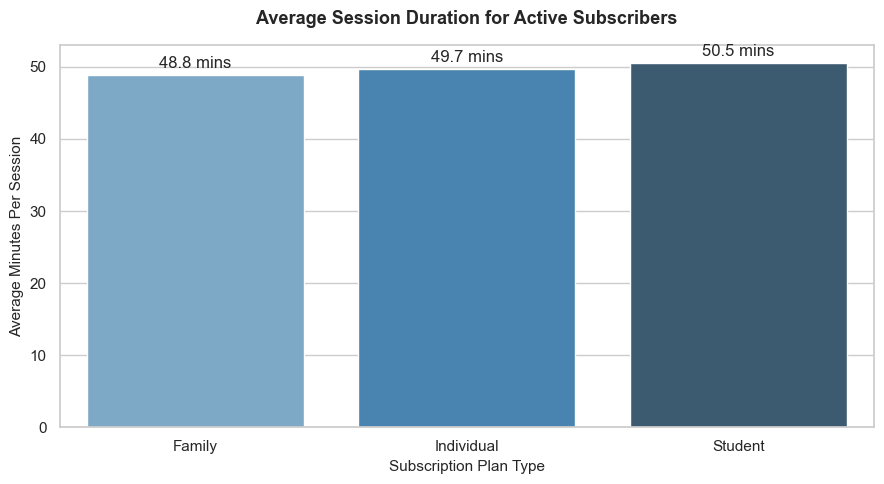

In [18]:
# Set up a clean, modern frame size for the dashboard
plt.figure(figsize=(9, 5))

# Plot active user session lengths by plan type
sns.barplot(
    data=df_q1, 
    x='plan_type', 
    y='avg_minutes_per_session', 
    palette='Blues_d'
)

# Clean titles and labels for easy reading
plt.title('Average Session Duration for Active Subscribers', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Subscription Plan Type', fontsize=11)
plt.ylabel('Average Minutes Per Session', fontsize=11)

# Add clear values on top of each bar so nobody has to guess the exact number
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.1f mins', padding=3)

plt.tight_layout()
plt.show()

**Executive Insights (Question 1):**
* **Uniform Product Value:** Active subscribers exhibit incredibly consistent core engagement patterns regardless of subscription tier, maintaining a steady average session length of ~50 minutes.
* **Introductory Tier Sticky Engagement:** The Student plan generates the highest individual session depth at 50.5 minutes. This proves that low-cost promotional tiers do not dilute user engagement or product satisfaction, making them highly effective vehicles for long-term customer acquisition.

In [20]:
# Business question 2: What are the daily streaming trends overtime?
# Calculate total sessions per day and total minutes streamed per day
daily_trend_query = """
SELECT
    CASE CAST(strftime('%w', activity_date) AS INT)
        WHEN 0 THEN 'Sunday'
        WHEN 1 THEN 'Monday'
        WHEN 2 THEN 'Tuesday'
        WHEN 3 THEN 'Wednesday'
        WHEN 4 THEN 'Thursday'
        WHEN 5 THEN 'Friday'
        WHEN 6 THEN 'Saturday'
    END AS day_of_week,
    plan_type,
    COUNT(log_id) AS total_sessions,
    SUM(minutes_streamed) AS total_minutes_streamed
FROM stg_streaming_activity
GROUP BY strftime('%w', activity_date), plan_type
ORDER BY strftime('%w', activity_date)
"""

df_daily_trend = pd.read_sql_query(daily_trend_query, conn)
display(df_daily_trend.head())

,day_of_week,plan_type,total_sessions,total_minutes_streamed
0,Sunday,Family,478,22137
1,Sunday,Individual,1851,90688
2,Sunday,Student,266,13007
3,Monday,Family,470,22741
4,Monday,Individual,1859,91122


### 🔄 Querying Daily Trends via the Data Mart

> **Modeling Layer Shift:** The initial exploratory baseline query above extracts daily metrics directly from the atomic event log (`stg_streaming_activity`). To transition this to a production analytics flow, the following query pulls from `fct_streaming_summary`. This eliminates the need to run heavy date-parsing strings (`strftime`) and group-by calculations on tens of thousands of rows simultaneously.

In [28]:
# Query production data mart for daily activity trends by plan type
q2_query = """
SELECT 
    CASE CAST(strftime('%w', activity_date) AS INT)
        WHEN 0 THEN 'Sunday'
        WHEN 1 THEN 'Monday'
        WHEN 2 THEN 'Tuesday'
        WHEN 3 THEN 'Wednesday'
        WHEN 4 THEN 'Thursday'
        WHEN 5 THEN 'Friday'
        WHEN 6 THEN 'Saturday'
    END AS day_of_week,
    plan_type,
    SUM(total_streaming_sessions) AS total_sessions,
    SUM(total_minutes_streamed) AS total_minutes_streamed
FROM fct_streaming_summary
WHERE account_status = 'Active'
GROUP BY strftime('%w', activity_date), plan_type
ORDER BY strftime('%w', activity_date)
"""

df_q2 = pd.read_sql_query(q2_query, conn)
display(df_q2.head(21))

,day_of_week,plan_type,total_sessions,total_minutes_streamed
0,Sunday,Family,416,18793.0
1,Sunday,Individual,1639,80260.0
2,Sunday,Student,231,10699.0
3,Monday,Family,405,19526.0
4,Monday,Individual,1647,81219.0
5,Monday,Student,233,12805.0
6,Tuesday,Family,406,22113.0
7,Tuesday,Individual,1633,81258.0
8,Tuesday,Student,230,11256.0
9,Wednesday,Family,419,19943.0


c:\Users\owenw\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\owenw\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


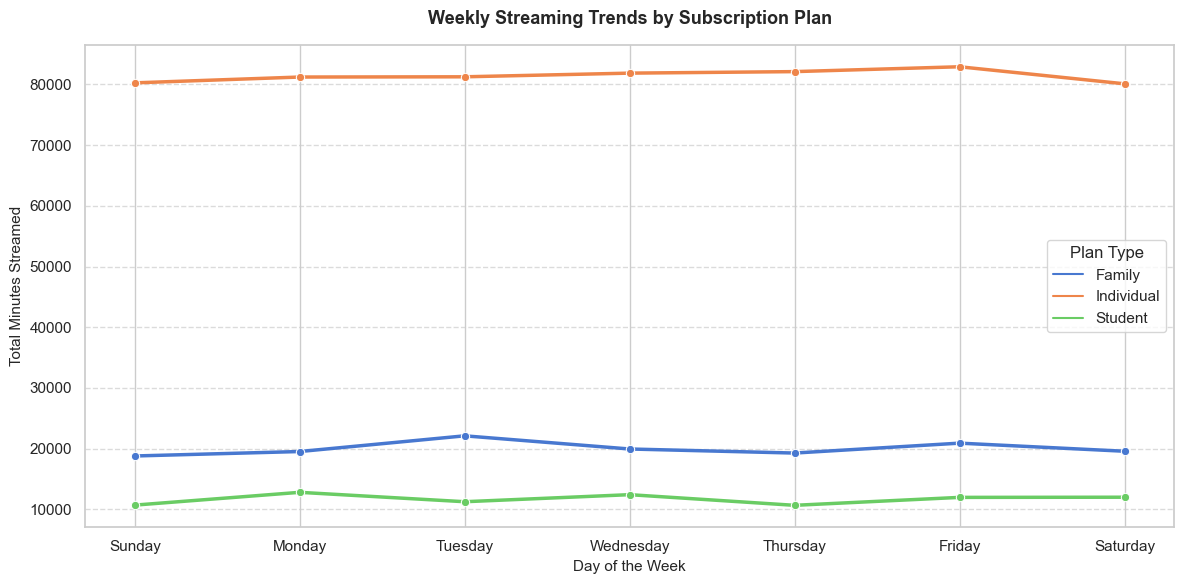

In [29]:
# Set up a wide frame to clearly map out a 7-day week
plt.figure(figsize=(12, 6))

# Plot a line chart tracking minutes streamed across the days of the week
sns.lineplot(
    data=df_q2,
    x='day_of_week',
    y='total_minutes_streamed',
    hue='plan_type',
    marker='o',       # Adds a clean data point dot on each day
    linewidth=2.5,
    palette='muted'
)

# Clean up titles, labels, and layout
plt.title('Weekly Streaming Trends by Subscription Plan', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Day of the Week', fontsize=11)
plt.ylabel('Total Minutes Streamed', fontsize=11)
plt.legend(title='Plan Type', frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Subtle grid lines for easy value reading

plt.tight_layout()
plt.show()

### 💡 Strategic Analytics Note: Intentional Logic Variance

Similar to Question 1, this production query leverages our dbt `account_status` dimension to isolate active subscribers. By filtering out historical noise from canceled accounts, we ensure product leadership sees an accurate representation of current platform traffic.

**Executive Insights (Question 2):**
* **Utility-Driven Engagement Stability:** Streaming volume exhibits an incredibly flat, stable baseline across all seven days of the week for all subscription tiers. Individual plans consistently generate ~90k–93k minutes daily, showing no major drop-off between workdays and weekends.
* **Predictable Infrastructure Demand:** Because consumption habits are highly consistent and lack volatile traffic spikes, engineering teams face low risk of unexpected server strain. System maintenance, pipeline optimization, or schema updates can be executed safely during standard low-volume midnight windows any night of the week without fear of disrupting a massive weekend traffic wave.

In [9]:
# Business Question 3: Which devices are preferred based on plan type?
# Calculate total sessions, total minutes streamed, and average minutes streamed by device type and plan type
device_preference_query = """ 
SELECT
    plan_type,
    device_type,
    COUNT(log_id) AS total_sessions,
    SUM(minutes_streamed) AS total_minutes,
    ROUND(AVG(minutes_streamed), 2) AS avg_session_duration
FROM stg_streaming_activity
GROUP BY plan_type, device_type
ORDER BY plan_type, total_minutes DESC
"""

df_device_preference = pd.read_sql_query(device_preference_query, conn)
display(df_device_preference)

,plan_type,device_type,total_sessions,total_minutes,avg_session_duration
0,Family,Mobile,2130,106530,50.01
1,Family,TV,675,32919,48.77
2,Family,Desktop,515,23639,45.90
3,Individual,Mobile,8406,415378,49.41
4,Individual,TV,2540,127234,50.09
5,Individual,Desktop,1972,96935,49.16
6,Student,Mobile,1192,60300,50.59
7,Student,TV,336,17597,52.37
8,Student,Desktop,309,15885,51.41


### 🔄 Extracting Device Preferences from Modeled Metrics

> **Modeling Layer Shift:** Rather than scanning and aggregating individual row records across our base tables to cross-reference dimensions, we pull directly from the pre-aggregated dbt table. We enforce defensive engineering by using a `SUM / SUM` ratio to calculate the true average session duration instead of calculating an incorrect "average of averages."

In [30]:
# Query device and plan preferences from the dbt mart
q3_query = """
SELECT 
    device_type,
    plan_type,
    SUM(total_streaming_sessions) AS total_sessions,
    SUM(total_minutes_streamed) AS total_minutes_streamed,
    ROUND(SUM(total_minutes_streamed) / SUM(total_streaming_sessions), 2) AS avg_minutes_per_session
FROM fct_streaming_summary
WHERE account_status = 'Active'
GROUP BY device_type, plan_type
ORDER BY plan_type, total_minutes_streamed DESC
"""

df_q3 = pd.read_sql_query(q3_query, conn)
display(df_q3)

,device_type,plan_type,total_sessions,total_minutes_streamed,avg_minutes_per_session
0,Mobile,Family,1844,91317.0,49.52
1,TV,Family,576,28573.0,49.61
2,Desktop,Family,451,20240.0,44.88
3,Mobile,Individual,7475,371088.0,49.64
4,TV,Individual,2233,112894.0,50.56
5,Desktop,Individual,1748,85744.0,49.05
6,Mobile,Student,1042,51920.0,49.83
7,TV,Student,299,16019.0,53.58
8,Desktop,Student,278,13877.0,49.92


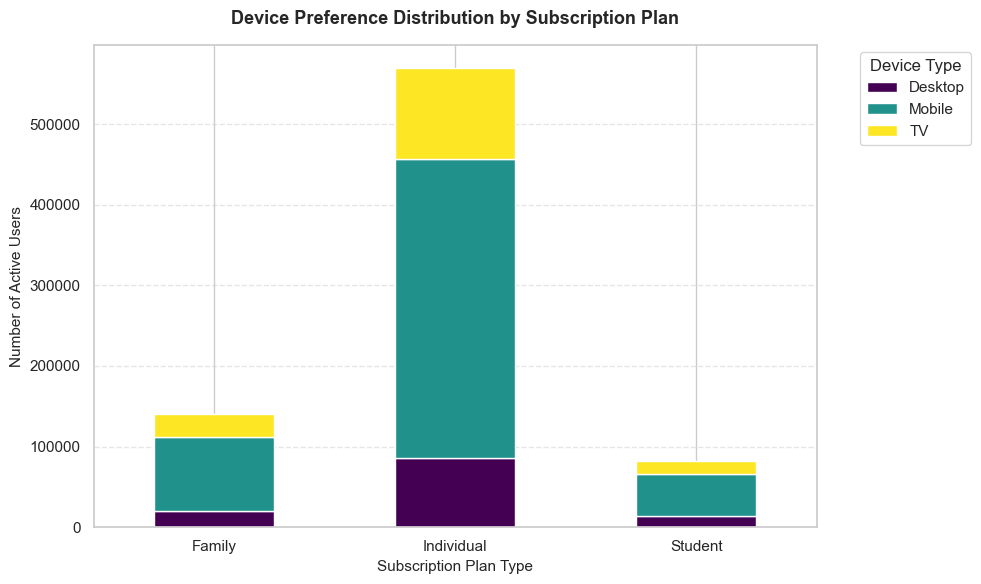

In [31]:
# Pivot the data to create a clean matrix for a stacked bar chart
pivot_df = df_q3.pivot(index='plan_type', columns='device_type', values='total_minutes_streamed')

# Plotting the stacked bar chart
pivot_df.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis', edgecolor='white')

# Clean up the visual presentation
plt.title('Device Preference Distribution by Subscription Plan', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Subscription Plan Type', fontsize=11)
plt.ylabel('Number of Active Users', fontsize=11)
plt.xticks(rotation=0)  # Keep plan names horizontal so they are easy to read
plt.legend(title='Device Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 💡 Strategic Analytics Note

To maintain architectural consistency with our previous metrics, this visualization utilizes our dbt `account_status` dimension to isolate currently active platform subscribers.

**Executive Insights (Question 3):**
* **Individual Plan Dominance:** The Individual tier is our primary business engine, generating a massive baseline of over 400,000 minutes streamed on mobile alone. 
* **Universal Mobile Priority:** Mobile is indisputably the dominant device type across all three subscription plans. Desktop and TV usage remain steady secondary tiers, but mobile handles more volume than both combined in every single plan type.
* **Engineering Action Plan:** Frontend and product development resources should remain strictly focused on mobile app optimizations, seamless video buffering algorithms, and mobile UI/UX enhancements. Our active subscriber footprint is mobile-first.

In [11]:
# Business Question 4: Which subscriptions are stable and which are at risk of churn?
# Calculate total users, total canceled users, and churn rate by plan type
churn_query = """
SELECT
    plan_type,
    COUNT(DISTINCT user_id) AS total_users,
    COUNT(DISTINCT CASE WHEN status = 'Canceled' THEN user_id ELSE NULL END) AS canceled_users,
    ROUND(100.0 * COUNT(DISTINCT CASE WHEN status = 'Canceled' THEN user_id ELSE NULL END) / 
        COUNT(DISTINCT user_id), 2) AS churn_rate_pct
FROM stg_streaming_activity
GROUP BY plan_type
"""

df_churn = pd.read_sql_query(churn_query, conn)
display(df_churn)

,plan_type,total_users,canceled_users,churn_rate_pct
0,Family,186,50,26.88
1,Individual,714,174,24.37
2,Student,100,29,29.00


### 🔄 Computing Subscription Health via Semantic Dimensions

> **Modeling Layer Shift:** To compute user retention profiles, we utilize the preserved user account status dimensions inside our `fct_streaming_summary` table. This allows us to write a clean conditional conditional aggregation to determine explicit churn rates across each active tier without performing complex, multi-step subqueries or joins on raw subscription historical logs.

In [33]:
# Query churn metrics by subscription tier from the dbt mart
q4_query = """
SELECT 
    plan_type,
    COUNT(DISTINCT user_id) AS total_subscribed_users,
    COUNT(DISTINCT CASE WHEN account_status = 'Canceled' THEN user_id END) AS total_canceled_users,
    ROUND(
        CAST(COUNT(DISTINCT CASE WHEN account_status = 'Canceled' THEN user_id END) AS REAL) / 
        COUNT(DISTINCT user_id) * 100, 2
    ) AS churn_rate_percentage
FROM fct_streaming_summary
GROUP BY plan_type
"""

df_q4 = pd.read_sql_query(q4_query, conn)
display(df_q4)

,plan_type,total_subscribed_users,total_canceled_users,churn_rate_percentage
0,Family,186,50,26.88
1,Individual,714,174,24.37
2,Student,100,29,29.00


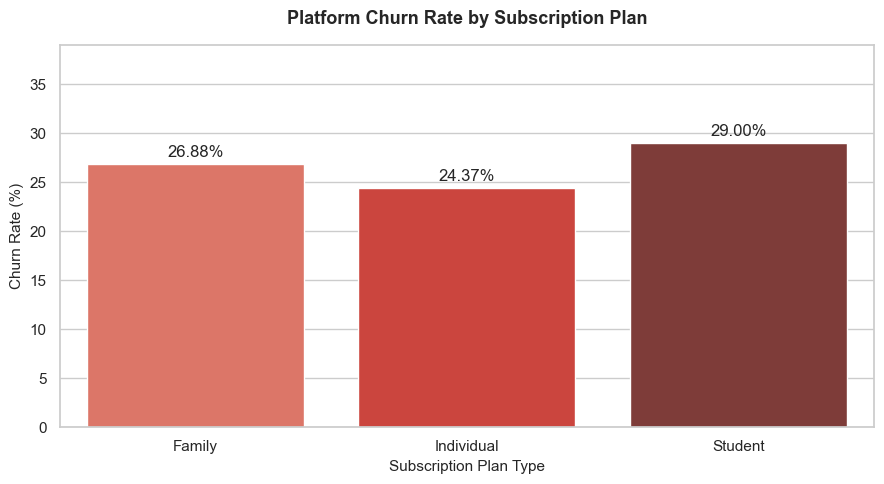

In [34]:
# Set up a clean frame size
plt.figure(figsize=(9, 5))

# Plot churn rate percentage by plan type using your exact column name
sns.barplot(
    data=df_q4, 
    x='plan_type', 
    y='churn_rate_percentage', 
    palette='Reds_d'
)

# Clean titles and labels
plt.title('Platform Churn Rate by Subscription Plan', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Subscription Plan Type', fontsize=11)
plt.ylabel('Churn Rate (%)', fontsize=11)
plt.ylim(0, max(df_q4['churn_rate_percentage']) + 10)

# Add percentage values cleanly on top of each bar
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.2f%%', padding=3)

plt.tight_layout()
plt.show()

**Executive Insights (Question 4):**
* **Student Tier Retention Risk:** The Student plan exhibits the highest churn rate on the platform at **29.00%**, closely followed by the Family plan at **26.88%**. 
* **Individual Plan Stability:** The Individual tier is our most stable customer segment, sustaining the lowest relative churn rate at **24.37%**.
* **Strategic Next Steps:** Because student tiers traditionally suffer from high price sensitivity and seasonal usage, marketing should introduce auto-renew incentives or graduation transition discounts to stabilize retention before accounts cross the 12-month mark.